# PCA analysis pipeline

This notebook performs the core PCA workflow on cleaned driving behavior data.

**Input:**

- `data/EEDA_cleaned.csv` (generated by `0_preprocessing.ipynb`)

**Main outputs:**

Saved under `results/` (organized by event via helper functions):
- cleaned subsets for PCA
- variances and eigenvalues
- PCA components/loadings
- biplots and cos2 plots

**Run context**

Run this notebook from the project root directory so relative paths resolve correctly.

In [1]:
import gc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from xarray.util.generate_ops import inplace

warnings.simplefilter(action='ignore', category=FutureWarning)
import dataframe_image as dfi
import os
import math
from  matplotlib.ticker import PercentFormatter
sns.set_style("white")
# sns.set_context("notebook")
sns.set_theme(style="ticks", palette="husl")
from pathlib import Path
import cv2
# set dask dashboard
import dask
import dask.array as da
dask.config.set({'dataframe.query-planning': True})
import dask.dataframe as dd
from scipy.spatial.transform import Rotation as R
# pd.options.mode.chained_assignment = None  # default='warn'
from dask.distributed import Client
client = Client()  # start distributed scheduler locally.
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:53550,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 16
Started: Just now,Total memory: 64.00 GiB
Comm: tcp://127.0.0.1:53562,Total threads: 4
Dashboard: http://127.0.0.1:53567/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:53553,


# 1. Load data and resampling

In [2]:
# Check and create 'data' and 'results' folders if they do not exist
data_folder = 'data'
results_folder = 'results'

if not os.path.exists(data_folder):
    os.makedirs(data_folder)
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

# Assign folder paths to variables for later use
DATA_DIR = data_folder
RESULTS_DIR = results_folder

# Load cleaned data 
# Columns to load
cols = ['timestamp_REF','UnixTimeStamp','TobiiTimeStamp','Auto_TobiiTimeStamp',
        'uid', 'Condition','Event','eye_theta_h','eye_theta_v','streeringDegree',
        'CarYaw_degrees','CarRoll_degrees', 'CarPitch_degrees','RelativeHeadYaw_degrees',
        'RelativeHeadPitch_degrees', 'RelativeHeadRoll_degrees']
df = dd.read_csv(os.path.join(DATA_DIR, 'EEDA_cleaned.csv'), usecols=cols).compute()
df.head()

,timestamp_REF,UnixTimeStamp,TobiiTimeStamp,uid,Auto_TobiiTimeStamp,Condition,Event,streeringDegree,eye_theta_h,eye_theta_v,CarYaw_degrees,CarPitch_degrees,CarRoll_degrees,RelativeHeadYaw_degrees,RelativeHeadPitch_degrees,RelativeHeadRoll_degrees
0,1970-01-01 02:56:39.665039062+00:00,1.630156e+09,10599.665039,017397ca31114170abc2ff61a217460b,10599.665039,Autonomous,NoEv,-42.106627,-1.611504,-3.784578,74.761305,0.847228,0.280716,3.099670,0.210684,5.025472
1,1970-01-01 02:56:39.686523437+00:00,1.630156e+09,10599.686523,017397ca31114170abc2ff61a217460b,10599.686523,Autonomous,NoEv,-42.106627,-1.539683,-3.805523,74.720284,0.850861,0.273172,2.883921,-0.249197,4.662842
2,1970-01-01 02:56:39.699218750+00:00,1.630156e+09,10599.686523,017397ca31114170abc2ff61a217460b,10599.699219,Autonomous,NoEv,-42.106627,-1.539683,-3.805523,74.720284,0.850861,0.273172,2.883921,-0.249197,4.662842
3,1970-01-01 02:56:39.721679687+00:00,1.630156e+09,10599.721680,017397ca31114170abc2ff61a217460b,10599.721680,Autonomous,NoEv,-42.132882,-1.098943,-3.900335,74.650599,0.830270,0.260069,2.911437,-0.207017,4.638311
4,1970-01-01 02:56:39.743164062+00:00,1.630156e+09,10599.743164,017397ca31114170abc2ff61a217460b,10599.743164,Autonomous,NoEv,-42.132882,-0.994679,-3.919528,74.621516,0.819260,0.252394,2.890011,-0.181404,4.623228


Inspect original sampling rate

In [3]:
# Ensure datetime for timestamp reference
df['timestamp_REF'] = pd.to_datetime(df.Auto_TobiiTimeStamp, utc=True, unit='s', origin='unix')

In [4]:
# Function to calculate time passed in seconds from the first timestamp
def calculate_time_passed(group):
    first_timestamp = group['timestamp_REF'].min()
    group['time'] = (group['timestamp_REF'] - first_timestamp).dt.total_seconds().round(2)
    return group

df = df.groupby('uid').apply(calculate_time_passed).reset_index(drop=True)
df.head()

,timestamp_REF,UnixTimeStamp,TobiiTimeStamp,uid,Auto_TobiiTimeStamp,Condition,Event,streeringDegree,eye_theta_h,eye_theta_v,CarYaw_degrees,CarPitch_degrees,CarRoll_degrees,RelativeHeadYaw_degrees,RelativeHeadPitch_degrees,RelativeHeadRoll_degrees,time
0,1970-01-01 02:56:39.665039062+00:00,1.630156e+09,10599.665039,017397ca31114170abc2ff61a217460b,10599.665039,Autonomous,NoEv,-42.106627,-1.611504,-3.784578,74.761305,0.847228,0.280716,3.099670,0.210684,5.025472,0.00
1,1970-01-01 02:56:39.686523437+00:00,1.630156e+09,10599.686523,017397ca31114170abc2ff61a217460b,10599.686523,Autonomous,NoEv,-42.106627,-1.539683,-3.805523,74.720284,0.850861,0.273172,2.883921,-0.249197,4.662842,0.02
2,1970-01-01 02:56:39.699218750+00:00,1.630156e+09,10599.686523,017397ca31114170abc2ff61a217460b,10599.699219,Autonomous,NoEv,-42.106627,-1.539683,-3.805523,74.720284,0.850861,0.273172,2.883921,-0.249197,4.662842,0.03
3,1970-01-01 02:56:39.721679687+00:00,1.630156e+09,10599.721680,017397ca31114170abc2ff61a217460b,10599.721680,Autonomous,NoEv,-42.132882,-1.098943,-3.900335,74.650599,0.830270,0.260069,2.911437,-0.207017,4.638311,0.06
4,1970-01-01 02:56:39.743164062+00:00,1.630156e+09,10599.743164,017397ca31114170abc2ff61a217460b,10599.743164,Autonomous,NoEv,-42.132882,-0.994679,-3.919528,74.621516,0.819260,0.252394,2.890011,-0.181404,4.623228,0.08


In [5]:
def plot_sampling_rate_and_time_diff(df, title='Original', uid_col='uid', timestamp_col='timestamp_REF', time_col='time'):
    """
    Plot sampling rate and time difference over time for a given dataframe.
    Args:
        df (pd.DataFrame): The dataframe to plot.
        title (str): The title of the plot.
        uid_col (str): The column name of the uid.
        timestamp_col (str): The column name of the timestamp.
        time_col (str): The column name of the time.
    """
    data = df.copy()
    data[timestamp_col] = pd.to_datetime(data[timestamp_col], errors='coerce')
    data = data.sort_values([uid_col, timestamp_col])

    data['time_diffs'] = data.groupby(uid_col)[timestamp_col].diff().dt.total_seconds()
    data.loc[data['time_diffs'] <= 0, 'time_diffs'] = np.nan
    data['sampling_rate'] = 1.0 / data['time_diffs']

    # Plot 1: Sampling rate per participant
    fig1, ax1 = plt.subplots(figsize=(16, 6))
    sns.boxplot(x=uid_col, y='sampling_rate', data=data, ax=ax1)
    ax1.set_title(f'{title} Sampling Rate by UID')
    ax1.set_xlabel('UID')
    ax1.set_ylabel('Sampling Rate (samples/sec)')
    ax1.tick_params(axis='x', rotation=80)
    fig1.tight_layout()

    # Plot 2: Time difference over time
    fig2, ax2 = plt.subplots(figsize=(6, 2))
    sns.scatterplot(x=time_col, y='time_diffs', data=data, s=10, ax=ax2)
    ax2.set_title(f'{title} Time Difference Over Time')
    ax2.set_xlabel('Time from start (s)')
    ax2.set_ylabel('Δt (s)')
    fig2.tight_layout()

In [23]:
# Visualize original sampling rate and timestamp differences over time
# plot_sampling_rate_and_time_diff(df)

## Choose data subset
We keep only variables to use for analysis and resample to 50Hz

In [6]:
# Drop unnecessary columns
df = df[['timestamp_REF','uid','Event','eye_theta_h', 'eye_theta_v',
                'CarYaw_degrees', 'CarPitch_degrees','CarRoll_degrees',
                'RelativeHeadYaw_degrees', 'RelativeHeadPitch_degrees',
                'RelativeHeadRoll_degrees', 'streeringDegree','Condition']]
df.head()

,timestamp_REF,uid,Event,eye_theta_h,eye_theta_v,CarYaw_degrees,CarPitch_degrees,CarRoll_degrees,RelativeHeadYaw_degrees,RelativeHeadPitch_degrees,RelativeHeadRoll_degrees,streeringDegree,Condition
0,1970-01-01 02:56:39.665039062+00:00,017397ca31114170abc2ff61a217460b,NoEv,-1.611504,-3.784578,74.761305,0.847228,0.280716,3.099670,0.210684,5.025472,-42.106627,Autonomous
1,1970-01-01 02:56:39.686523437+00:00,017397ca31114170abc2ff61a217460b,NoEv,-1.539683,-3.805523,74.720284,0.850861,0.273172,2.883921,-0.249197,4.662842,-42.106627,Autonomous
2,1970-01-01 02:56:39.699218750+00:00,017397ca31114170abc2ff61a217460b,NoEv,-1.539683,-3.805523,74.720284,0.850861,0.273172,2.883921,-0.249197,4.662842,-42.106627,Autonomous
3,1970-01-01 02:56:39.721679687+00:00,017397ca31114170abc2ff61a217460b,NoEv,-1.098943,-3.900335,74.650599,0.830270,0.260069,2.911437,-0.207017,4.638311,-42.132882,Autonomous
4,1970-01-01 02:56:39.743164062+00:00,017397ca31114170abc2ff61a217460b,NoEv,-0.994679,-3.919528,74.621516,0.819260,0.252394,2.890011,-0.181404,4.623228,-42.132882,Autonomous


In [7]:
# Define custom aggregator functions
aggregation_dict = {
        'Event': 'first',
        'eye_theta_h': 'mean',
        'eye_theta_v': 'mean',
        'CarYaw_degrees': 'mean',
        'CarPitch_degrees': 'mean',
        'CarRoll_degrees': 'mean',
        'RelativeHeadYaw_degrees':'mean',
        'RelativeHeadPitch_degrees':'mean',
        'RelativeHeadRoll_degrees':'mean',
        'streeringDegree':'mean',
        'Condition':'first',
    }

In [8]:
df.columns

Index(['timestamp_REF', 'uid', 'Event', 'eye_theta_h', 'eye_theta_v',
       'CarYaw_degrees', 'CarPitch_degrees', 'CarRoll_degrees',
       'RelativeHeadYaw_degrees', 'RelativeHeadPitch_degrees',
       'RelativeHeadRoll_degrees', 'streeringDegree', 'Condition'],
      dtype='object')

## Resampling
Run the commented code in case you suspect of repeated samples (two samples with the same timestamp)

In [82]:
# Define the columns you want to process
# columns_to_process = ['eye_theta_h', 'eye_theta_v', 'CarYaw_degrees',
#                       'CarPitch_degrees', 'CarRoll_degrees',
#                       'RelativeHeadYaw_degrees', 'RelativeHeadPitch_degrees',
#                       'RelativeHeadRoll_degrees']

# # Function to handle repeated samples on a column
# df = df.groupby('uid').apply(
#     lambda group: group.assign(
#         **{col: group[col].where(~group[col].duplicated(keep='first'), np.nan) for col in columns_to_process}
#     )
# ).reset_index(drop=True)

# # Interpolate NaN values linearly for the specified columns
# df[columns_to_process] = df[columns_to_process].interpolate(method='linear')

# # Display the cleaned DataFrame
# df.head()

In [9]:
# Define the resampling function
def resample_data_by_uid(df):
    """
    Resamples data from high frequency to 50Hz for each UID.
    Numerical columns are aggregated, and non-numerical are transformed.
    """
    # Group by 'uid' and apply the resampling
    resampled_groups = df.groupby('uid').apply(
        # Convert columns of object dtype to their inferred types
        lambda group: group.set_index('timestamp_REF').resample('20L').agg(aggregation_dict).infer_objects(copy=False).interpolate(method='linear').ffill().bfill()
    ).reset_index()

    return resampled_groups

# Only delete df after resampling, and check if df exists before calling the function
if 'df' in locals():
    # Resample the data to 50 Hz for each UID
    resampled_df = resample_data_by_uid(df)
    # Drop the original DataFrame to free up memory
    del df
    print("Your df was deleted to free memory, now you are working with 'resampled_df'.")
else:
    print("df is not defined. Please make sure your original DataFrame is loaded before resampling.")

Your df was deleted to free memory, now you are working with 'resampled_df'.


In [10]:
# Calculate time passed in seconds from the first timestamp
resampled_df = resampled_df.groupby('uid').apply(calculate_time_passed).reset_index(drop=True)
resampled_df.head()

,uid,timestamp_REF,Event,eye_theta_h,eye_theta_v,CarYaw_degrees,CarPitch_degrees,CarRoll_degrees,RelativeHeadYaw_degrees,RelativeHeadPitch_degrees,RelativeHeadRoll_degrees,streeringDegree,Condition,time
0,017397ca31114170abc2ff61a217460b,1970-01-01 02:56:39.660000+00:00,NoEv,-1.611504,-3.784578,74.761305,0.847228,0.280716,3.099670,0.210684,5.025472,-42.106627,Autonomous,0.00
1,017397ca31114170abc2ff61a217460b,1970-01-01 02:56:39.680000+00:00,NoEv,-1.539683,-3.805523,74.720284,0.850861,0.273172,2.883921,-0.249197,4.662842,-42.106627,Autonomous,0.02
2,017397ca31114170abc2ff61a217460b,1970-01-01 02:56:39.700000+00:00,NoEv,-1.319313,-3.852929,74.685442,0.840566,0.266620,2.897679,-0.228107,4.650577,-42.119755,Autonomous,0.04
3,017397ca31114170abc2ff61a217460b,1970-01-01 02:56:39.720000+00:00,NoEv,-1.098943,-3.900335,74.650599,0.830270,0.260069,2.911437,-0.207017,4.638311,-42.132882,Autonomous,0.06
4,017397ca31114170abc2ff61a217460b,1970-01-01 02:56:39.740000+00:00,NoEv,-0.994679,-3.919528,74.621516,0.819260,0.252394,2.890011,-0.181404,4.623228,-42.132882,Autonomous,0.08


In [24]:
# plot_sampling_rate_and_time_diff(resampled_df, title='Resampled')

# 2. Applying PCA
Useful packages and functions

In [25]:
import scipy as sp
from scipy.stats import chi2
from sklearn.covariance import MinCovDet
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm  # library for progress bar
import time  # simulating elapsed time 

In [26]:
# Robust Mahalonibis Distance
def robust_mahalanobis_method_dask(df, md_name='',outlier_name='', p_md_name='', cut=0.001):
    """
    Calculate a robust version of Mahalanobis distances for each data subset,
    using the Minimum Covariance Determinant (MCD) method.
    Args:
        df (pd.DataFrame): Dataframe to calculate Mahalanobis distances for.
        md_name (str): Name of the Mahalanobis distance column.
        outlier_name (str): Name of the outlier column.
        p_md_name (str): Name of the probability of the Mahalanobis distance column.
        cut (float): Cut-off point for the Mahalanobis distance.
    Returns:
        pd.DataFrame: DataFrame with Mahalanobis distances and outlier flags
    """
    #Minimum covariance determinant
    rng = np.random.RandomState(0)
    real_cov = np.cov(df.values.T)
    # print(df.columns)
    # print(real_cov)
    # Check if the covariance matrix is all zeros
    if np.all(real_cov == 0):
        # Check the dimensions of real_cov
        if real_cov.ndim == 0:  # Only one variable present
        # Create a 1x1 perturbation matrix
            perturbation = np.array(1e-2)  # Increase here
        else:  # Multiple variables present
            # Add a larger perturbation to the diagonal
            perturbation = np.eye(real_cov.shape[0]) * 1e-2  # Increase here
        real_cov += perturbation
        # print(f'PERTURBATION!: {real_cov}')
    # Calculate inverse covariance
    if df.shape[1] < 2:
        # Reshape when only one column in used (e.g., 'SteeringInput')
        X = rng.multivariate_normal(mean=np.mean(df, axis=0), cov=real_cov.reshape((1,1)), 
            size= round(len(df) * 0.5)) # 50% of the data
        cov = MinCovDet(random_state=0,support_fraction=0.8).fit(X) #calculate covariance
        mcd = cov.covariance_ #robust covariance metric
        robust_mean = cov.location_  #robust mean
        inv_covmat = sp.linalg.inv(mcd) #inverse of covariance matrix
    else:
        X = rng.multivariate_normal(mean=np.mean(df, axis=0), cov=real_cov, size= round(len(df) * 0.5))
        cov = MinCovDet(random_state=0,support_fraction=0.8).fit(X) #calculate covariance
        mcd = cov.covariance_ #robust covariance metric
        robust_mean = cov.location_  #robust mean
        inv_covmat = sp.linalg.inv(mcd) #inverse of covariance matrix

    # Robust M-Distance
    x_minus_mu = df - robust_mean
    # Transform data into dask arrays
    x_minus_mu_dask = da.from_array(x_minus_mu.to_numpy(), chunks=(min(x_minus_mu.shape[0], 10000), df.shape[1]))
    mahal = da.sqrt(da.diagonal(da.dot(da.dot(x_minus_mu_dask,inv_covmat), x_minus_mu_dask.T)))
    # Calculate md
    md = mahal.compute()
    # Compute the chi-squared cumulative probability distribution to transfer the md2 into probabilities
    probability_md = 1 - chi2.cdf(md, df=df.shape[1])

    # Save md values and probabilities to df column
    md_df = pd.DataFrame({md_name:md,p_md_name:probability_md})
    # Set a Chi2 cut-off point using probability of 0.01 (99.5% Chi2 quantile)
    # Degrees of freedom (df) = number of variables
    threshold = chi2.ppf((1-cut), df=df.shape[1])
    # STD threshold, assuming 'md' contains your computed distances
    # mean_md = np.mean(md)
    # std_md = np.std(md)
    # threshold_3std = mean_md + 4 * std_md
    # Flag outliers as md > threshold
    md_df[outlier_name] = md_df[md_name] > threshold
    return md_df

In [27]:
# Mahalanobis distance fucntion to be used in the PCA analysis
def mahalanobis_for_pca(df):
    """
    Calculate Mahalanobis distances for each data subset.
    Args:
        df (pd.DataFrame): Input DataFrame containing the data to process
    Returns:
        pd.DataFrame: DataFrame with Mahalanobis distances and outlier flags 
        for all set of variables
    """
    ## ---- EYE columns ----
    mds_eye = robust_mahalanobis_method_dask(df=df[['eye_theta_h', 'eye_theta_v']], md_name='md_eye',
    outlier_name='eye_outlier', p_md_name='p_md_eye', cut=0.10).reset_index(drop=True)
    ## ---- HEAD columns ----
    mds_head = robust_mahalanobis_method_dask(df=df[['RelativeHeadYaw_degrees','RelativeHeadPitch_degrees',
     'RelativeHeadRoll_degrees']], md_name='md_head',outlier_name='head_outlier', p_md_name='p_md_head', cut=0.20).reset_index(drop=True)
    ## ---- CAR columns ----
    mds_car = robust_mahalanobis_method_dask(df=df[['CarYaw_degrees', 'CarPitch_degrees', 'CarRoll_degrees']],
     md_name='md_car',outlier_name='car_outlier', p_md_name='p_md_car', cut=0.10).reset_index(drop=True)
    ## ---- Steering ----
    mds_steer = robust_mahalanobis_method_dask(df=df[['streeringDegree']], md_name='md_steering',
    outlier_name='steering_outlier', p_md_name='p_md_steer', cut=0.10).reset_index(drop=True)

    ## save md and outlier data
    md_df = pd.concat([df.reset_index(drop=True),mds_eye, mds_head, mds_car,mds_steer], axis=1)
    final_df = md_df.drop(columns=['md_eye','p_md_eye','md_head','p_md_head','md_car','p_md_car',
    'md_steering','p_md_steer'])
    return final_df

# Function to interpolate NaN values in a subset of data
def interpolate_nan_pca(df):
    """
    Interpolate NaN values in a subset of data.
    Args:
        df (pd.DataFrame): Input DataFrame containing the data to process
    Returns:
        pd.DataFrame: DataFrame with interpolated NaN values
    """
    # 1. Convert 'outlier' column values to NaN where True
    # -- Eye
    df.loc[df['eye_outlier'], ['eye_theta_h', 'eye_theta_v']] = np.nan

    # -- Head
    df.loc[df['head_outlier'], ['RelativeHeadYaw_degrees', 'RelativeHeadPitch_degrees','RelativeHeadRoll_degrees']] = np.nan
    # -- Car
    df.loc[df['car_outlier'], ['CarRoll_degrees','CarYaw_degrees', 'CarPitch_degrees']] = np.nan
    # -- Steering
    df.loc[df['steering_outlier'], ['streeringDegree']] = np.nan
    # Group by 'uid' and interpolate NaN values
    interpolated_df = df.groupby('conditions').apply(lambda group: group.interpolate(method='linear').ffill().bfill()).reset_index(drop=True)
    # cleaned_df = interpolated_df.drop(columns=['eye_outlier','head_outlier','car_outlier','steering_outlier','pupil_dilation_outlier'])
    return interpolated_df

# Function to clean a subset of data by detecting and interpolating outliers during PCA analysis
def clean_subset(df):
    """
    Clean a subset of data by detecting and interpolating outliers.
    Args:
        df (pd.DataFrame): Input DataFrame containing the data to process
    Returns:
        pd.DataFrame: DataFrame with interpolated NaN values
    """
    # Detect outliers in subset by md
    subset_md = df.pipe(mahalanobis_for_pca)
    # Interpolate detected outliers
    subset_interpolated = subset_md.pipe(interpolate_nan_pca)
    return subset_interpolated


In [28]:
def init_results_dirs(base_dir: str = "results", event: str | None = None):
    """
    Initialize results directory structure with per-event subfolders.

    Structure created:
        results/
          cleaned_new/ <event_dir>
          variances/   <event_dir>
          components/  <event_dir>
          eigenvalues/ <event_dir>
          biplots/     <event_dir>
          cos_plots/   <event_dir>

    Where <event_dir> is "event_<event>" if event is provided, otherwise "all_events".

    Args:
        base_dir: Base results directory.
        event: Optional event name.

    Returns:
        dict: Mapping of category name to absolute event-specific directory path. Includes key "base".
    """
    base_abs = os.path.abspath(base_dir)
    os.makedirs(base_abs, exist_ok=True)

    event_dirname = f"event_{event}" if (event and len(str(event)) > 0) else "all_events"

    categories = [
        "cleaned_new",
        "variances",
        "components",
        "eigenvalues",
        "biplots",
        "cos_plots",
    ]

    dirs: dict[str, str] = {"base": base_abs}
    for cat in categories:
        cat_parent = os.path.join(base_abs, cat)
        os.makedirs(cat_parent, exist_ok=True)
        cat_event_dir = os.path.join(cat_parent, event_dirname)
        os.makedirs(cat_event_dir, exist_ok=True)
        dirs[cat] = cat_event_dir

    return dirs

In [29]:
# Mapping of old labels to new labels
def map_labels(labels, label_mapping):
    """
    Maps each label in the given list using the provided mapping dictionary.

    Args:
        labels (list): List of original labels.
        label_mapping (dict): Mapping dictionary for label replacement.

    Returns:
        list: New list with mapped labels.
    """
    return [label_mapping.get(label, label) for label in labels]

# Define your label mapping (you can modify this as needed)
custom_mapping = {
    'eye_theta_h': 'Eye Horizontal',
    'eye_theta_v': 'Eye Vertical',
    'RelativeHeadYaw_degrees': 'Head Yaw',
    'RelativeHeadPitch_degrees': 'Head Pitch',
    'RelativeHeadRoll_degrees': 'Head Roll',
    'CarYaw_degrees': 'Car Yaw',
    'streeringDegree': 'Steering',
    'conditions': 'Condition',
}

# Function to plot a biplot of PCA scores and loadings
def biplot(score, coef, eigenvalues,
           labels=None,
           colors=None,
           explained_variance=None,
           vector_colors=None,
           scaled=None,
           vector_linewidth=None):
    """
    Plot a biplot of PCA scores and loadings.
    Args:
        score (np.ndarray): PCA scores.
        coef (np.ndarray): PCA loadings.
        eigenvalues (np.ndarray): Eigenvalues.
        labels (list): List of original labels.
        colors (list): List of colors for each label.
        explained_variance (list): List of explained variances.
        vector_colors (list): List of colors for each vector.
        scaled (bool): Whether to scale the vectors.
        vector_linewidth (float): Linewidth for the vectors.

    Returns:
        None: Plots the biplot.

    Raises:
        TypeError: If the input is not a PCA object.
    """
    # plt.rcParams.update({'font.size': 10})
    # Apply 90-degree rotation matrix to `score` and `coef`
    # rotation_matrix = np.array([[0, -1], [1, 0]])
    # Rotate the first two components of the scores
    # score = np.dot(score[:, :2], rotation_matrix)
    # Rotate the first two components of the loadings
    # coef = np.dot(coef[:, :2], rotation_matrix)
    xs = score[:, 0]
    ys = score[:, 1]
    n = coef.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())

    padding= 1.2 # 20% padding for axis and vector scaling
    padding_text = 1.1 # 10 % padding for text
    xlims = padding * np.max(np.abs(xs))
    ylims = padding * np.max(np.abs(ys))
    if colors is None:  # If no color information, plot all points gray
        plt.scatter(xs, ys, s=80, color='gray', alpha=0.5, edgecolor='gray')
    else:  # If color information is given, plot points with corresponding colors
        # plt.scatter(xs * scalex, ys * scaley, s=80, color=colors, alpha=0.5)
        plt.scatter(xs, ys, s=80, color=colors, alpha=0.5,edgecolor=colors)
    plt.xlim(-xlims * padding,xlims * padding)
    plt.ylim(-ylims* padding,ylims* padding)

    # Adjust the number of labels to match the number of coefficients
    original_labels = labels[:n]

    # Call the function to get the new mapped labels
    labels = map_labels(original_labels, custom_mapping)

    # --- Fix for arrow head aspect ratio ---
    # The problem is that plt.arrow's head_length and head_width are in data coordinates,
    # so if the axes are not square, the arrow heads get distorted.
    # Solution: Use ax.annotate with arrowprops, which handles head size in points (screen units).

    ax = plt.gca()
    # Set fixed axis limits
    fixed_x_min, fixed_x_max = -xlims, xlims  # Your specified x limits
    fixed_y_min, fixed_y_max = -ylims, ylims  # Your specified y limits

    # Set the fixed limits
    plt.xlim(fixed_x_min, fixed_x_max)
    plt.ylim(fixed_y_min, fixed_y_max)

    # Hide all spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Draw principal component vectors as arrows (using annotate for consistent arrow heads)
    for i in range(n):
        # Calculate arrow end point (arrow head)
        arrow_end_x = xlims * coef[i, 0]
        arrow_end_y = ylims * coef[i, 1]
        if scaled:
            # If scaled, you may want to adjust arrow length, but here we keep as is
            pass
        # Use annotate for arrow with head in points (screen units)
        ax.annotate(
            '', xy=(arrow_end_x, arrow_end_y), xytext=(0, 0),
            arrowprops=dict(
                arrowstyle='-|>,head_width=0.15,head_length=0.2',  # consistent head size
                color=vector_colors[i],
                lw=vector_linewidth,
                alpha=1,
                shrinkA=0, shrinkB=0,
                mutation_scale=18  # controls the size of the arrow head in points
            ),
        )
        # Position the label above the arrow head
        if labels is not None:
            va = 'bottom' if arrow_end_y > 0 else 'top'
            plt.text(arrow_end_x * padding_text, arrow_end_y * padding_text,
                     f"{labels[i]}\n({coef[i, 0]:.2f}, {coef[i, 1]:.2f})", color='black', ha='center',
                     va=va, fontdict=dict(fontsize=12), bbox=dict(facecolor='white', alpha=0.0001, edgecolor='white'))

    # --- Draw axis arrows with equal length and head size using annotate (for consistent appearance) ---
    # Define the length of the axis arrows (as a fraction of the axis range)
    axis_arrow_frac = 0.25  # 25% of axis range
    axis_arrow_length_x = (fixed_x_max - fixed_x_min) * axis_arrow_frac
    axis_arrow_length_y = (fixed_y_max - fixed_y_min) * axis_arrow_frac

    # Define the starting point (bottom left corner, with a small offset)
    axis_offset_frac = 0.05  # offset from the corner (in axes-fraction units)
    start_x = fixed_x_min + axis_offset_frac * (fixed_x_max - fixed_x_min)
    start_y = fixed_y_min + axis_offset_frac * (fixed_y_max - fixed_y_min)

    # Arrow style for both axes
    axis_arrowprops = dict(
        arrowstyle='-|>,head_width=0.25,head_length=0.35',
        color='black',
        lw=2.5,
        alpha=1,
        shrinkA=0, shrinkB=0,
        mutation_scale=18  # controls the size of the arrow head in points
    )

    # Draw y-axis arrow (vertical)
    ax.annotate(
        '', xy=(start_x, start_y + axis_arrow_length_y), xytext=(start_x, start_y),
        arrowprops=axis_arrowprops
    )

    # Draw x-axis arrow (horizontal)
    x_axis_arrow_end = start_x + axis_arrow_length_x - 0.5
    ax.annotate(
        '', xy=(x_axis_arrow_end, start_y), xytext=(start_x, start_y),
        arrowprops=axis_arrowprops
    )

    # Hide tick parameters
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove standard labels
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Add custom positioned labels using axis-fraction coordinates for fixed placement
    label_offset_frac = 0.012  # spacing from the arrows (closer)
    # Centered under the x-axis arrow (use actual shortened arrow midpoint converted to axes fraction)
    x_axis_arrow_mid_data = (start_x + x_axis_arrow_end) / 2
    x_axis_arrow_mid_frac = (x_axis_arrow_mid_data - fixed_x_min) / (fixed_x_max - fixed_x_min)
    ax.text(
        x_axis_arrow_mid_frac,
        axis_offset_frac - label_offset_frac,
        "PC{} ({:.1f}%)".format(1, explained_variance[0] * 100),
        fontsize=12,
        ha='center', va='top', transform=ax.transAxes
    )

    # Centered to the left of the y-axis arrow
    ax.text(
        axis_offset_frac - 0.006,
        axis_arrow_frac / 2 + axis_offset_frac,
        "PC{} ({:.1f}%)".format(2, explained_variance[1] * 100),
        fontsize=12,
        ha='right', va='center', rotation=90, transform=ax.transAxes
    )

    # Add a legend for the colors if provided
    if colors is not None:
        legend_elements = [
            Line2D([0], [0],
                   marker='o',
                   color='w',
                   markerfacecolor='#2A586E',
                   markersize=12,
                   label='Manual',
                   alpha=0.8),
            Line2D([0], [0],
                   marker='o',
                   color='w',
                   markerfacecolor='#cc2936',
                   markersize=12,
                   label='Autonomous',
                   alpha=0.8)
        ]
        plt.legend(handles=legend_elements, fontsize=12)


def get_pca_var(pca, subset_scaled, feature_names):
    # Validate input types
    if not isinstance(pca, PCA):
        raise TypeError("Expected a PCA object from sklearn.decomposition.PCA")

    # Compute coordinates
    coords = pca.components_.T * np.sqrt(pca.explained_variance_)

    # Compute correlations
    # Since we're using standardized data:
    cor = coords / np.std(subset_scaled, axis=0)

    # Compute cos2 (squared loadings or cosine similarity)
    cos2 = np.square(cor)

    # Compute contributions
    total_variance = np.sum(pca.explained_variance_)
    contrib = (cos2 * 100 * pca.explained_variance_) / total_variance

    # Create dataframes with feature names as the index
    coord_df = pd.DataFrame(coords, index=feature_names, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
    cor_df = pd.DataFrame(cor, index=feature_names, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
    cos2_df = pd.DataFrame(cos2, index=feature_names, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
    contrib_df = pd.DataFrame(contrib, index=feature_names, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

    return {
        'coord': coord_df,
        'cor': cor_df,
        'cos2': cos2_df,
        'contrib': contrib_df
    }

from matplotlib.patches import Circle
from matplotlib import colors as mcolors

def plot_cosine_similarity(cos2_df, title='', event='', time_point='', save=False, save_path: str | None = None):
    """
    Plot the cosine similarity of the PCA components.
    Args:
        cos2_df (pd.DataFrame): DataFrame containing cosine similarity values.
        title (str): Title of the plot.
        event (str): Event name.
        time_point (str): Time point.
        save (bool): Whether to save the plot.

    Returns:
        None: Plots the cosine similarity plot.
    """
    # Extract feature names directly from the DataFrame index
    feature_names = cos2_df.index

    # max_cos2_value = max(cos2_df['PC1'])  # color bar maximum limit
    max_cos2_value = 1  # color bar maximum limit
    # Create a custom colormap from white to #A2530E
    cmap = mcolors.LinearSegmentedColormap.from_list("", ["white", "#A2530E"])

    features, components = cos2_df.shape
    fig, ax = plt.subplots(figsize=(10, 8))
    if len(feature_names) > 10:
        num_fontsize = 10
    num_fontsize = 14
    ax.set_title(title, fontsize=18)

    # Plot each circle and add annotations
    for i in range(features):
        for j in range(components):
            value = cos2_df.iloc[i, j]
            color = cmap(value / max_cos2_value)  # Normalize the color
            circle = Circle((j, i), radius=np.sqrt(value) * 0.5, color=color, fill=True)
            ax.add_artist(circle)

            # Annotate the cos2 value at the center of the circle
            ax.text(
                j, i, f'{value:.2f}',
                color='lightgray',
                ha='center', va='center',
                fontsize=num_fontsize,  # Adjust font size for readability
            )

    # Setup axis limits and labels
    ax.set_xlim(-0.5, components - 0.5)
    ax.set_ylim(-0.5, features - 0.5)
    ax.set_xticks(np.arange(components))
    ax.set_yticks(np.arange(features))
    ax.set_xticklabels([f'PC{i+1}' for i in range(components)], rotation=0, fontsize=16)
    ax.set_yticklabels(feature_names, fontsize=16)
    ax.set_aspect('equal', 'box')

    # Add grid lines for clarity
    ax.hlines(np.arange(-0.5, features), xmin=-0.5, xmax=components - 0.5, color='grey', lw=0.5)
    ax.vlines(np.arange(-0.5, components), ymin=-0.5, ymax=features - 0.5, color='grey', lw=0.5)

    # Set outer border to gray by modifying the spines
    for spine in ax.spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(0.5)

    # Add a color bar on the right
    norm = mcolors.Normalize(vmin=0, vmax=max_cos2_value)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_label('$Cos^2$', fontsize=16)

    # Increase the number of ticks on the color bar for better granularity
    num_ticks = 6
    tick_values = np.linspace(0, max_cos2_value, num_ticks)
    cbar.set_ticks(tick_values)
    cbar.set_ticklabels([round(val, 2) for val in tick_values])
    cbar.ax.tick_params(labelsize=16)  # Set colorbar tick label size larger
    cbar.outline.set_visible(True)
    plt.tight_layout()
    if save:
        # This is the default dpi for the biplots to ensure good quality videos
        # Other formats will not allow videos to be created
        # plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
        plt.savefig(save_path, dpi=1000, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
    # plt.show()

## Calculate and visualize PCA

In [17]:
# Map each condition to a float number
label_mapping = {'Manual': 1, 'Autonomous': 0}
# with outliers
resampled_df.loc[:,'conditions'] = resampled_df['Condition'].map(label_mapping)
resampled_df.groupby(['Condition'])['uid'].nunique()

Condition
Autonomous    153
Manual        131
Name: uid, dtype: int64

In [30]:
# Calculate PCA
def visualize_event_pca(df, event='', features='', scaled=True, save_results=False, interactive=True, save_format=".pdf"):
    """
    Perform PCA for each time point (or event), save all plots and results if save_results=True,
    and optionally show interactive visualization if interactive=True.

    Parameters:
        df: DataFrame
        event: str, event name to filter by
        features: list of str, features to use for PCA
        scaled: bool, whether to scale features
        save_results: bool, whether to save plots and results
        interactive: bool, whether to show interactive widgets
        save_format: str, file extension for saved images (e.g., ".pdf", ".jpeg")
    """
    # Helper to format timestamp with two digits after decimal
    def format_timestamp(ts):
        try:
            # If ts is a float or can be converted to float
            return f"{float(ts):.2f}"
        except Exception:
            # If not, fallback to string
            return str(ts)

    # Helper to create DataFrame with timestamp and event columns
    def add_time_event(df, timestamp, event_name):
        df['Time'] = timestamp
        df['Event'] = event_name
        return df

    # Helper to plot biplot (for both save and show)
    def plot_biplot(pca_result, pca, eigenvalues, original_labels, colors, explained_variance, show=False, save_path=None, timestamp=None):
        sns.set_theme(style="white")
        plt.figure(figsize=(12, 8))
        plt.title(f"Time: {format_timestamp(timestamp)}", fontsize=16)
        biplot(
            pca_result,
            pca.components_.T,
            eigenvalues,
            original_labels,
            colors,
            explained_variance,
            vector_colors=['k'] * len(original_labels),
            scaled=scaled,
            vector_linewidth=1.1
        )
        if save_path:
            # This is the default dpi for the biplots to ensure good quality videos
            # Other formats will not allow videos to be created
            plt.savefig(save_path, dpi=1200, bbox_inches='tight', edgecolor='none')

            plt.close()
        elif show:
            plt.show()

    # Helper to plot cosine similarity (for both save and show)
    def plot_cos2(pca, subset_scaled, original_labels, show=False, save_path=None, event='', timestamp=None):
        pca_cos2 = get_pca_var(pca, subset_scaled, original_labels)
        cos2_matrix = pca_cos2['cos2']
        if save_path:
            plot_cosine_similarity(
                cos2_matrix,
                title='Cosine Similarity ($Cos^2$)',
                save=True,
                event=event,
                time_point=format_timestamp(timestamp),
                save_path=save_path
            )
            plt.close()
        elif show:
            plot_cosine_similarity(
                cos2_matrix,
                title='Cosine Similarity ($Cos^2$)',
                save=False,
                event=event,
                time_point=format_timestamp(timestamp),
                save_path=None
            )
            plt.show()

    # Get timestamps for the event or all
    timestamps = df[df['Event'] == event]['time'].unique() if event else df['time'].unique()

    # DataFrames to save data
    df_cleaned_ts = pd.DataFrame()
    df_event_components = pd.DataFrame()
    df_event_variance = pd.DataFrame()
    df_pca_results = pd.DataFrame()
    df_sorted_eigenvalues = pd.DataFrame()
    df_std_dev = pd.DataFrame()

    # Cache for interactive viewing
    cache = {}

    # Prepare directories if saving any artifacts
    _dirs = init_results_dirs(event=event if save_results else None) if save_results else {}

    with tqdm(total=len(timestamps), desc="Processing times", unit="", colour="green") as pbar:
        start_time = time.time()
        for i, timestamp in enumerate(timestamps):
            # Format timestamp for all downstream use
            formatted_timestamp = format_timestamp(timestamp)
            subset = df[df['time'] == timestamp]
            event_name = subset['Event'].unique()[0]
            pbar.set_postfix_str(f"Current Timestamp: {formatted_timestamp}")

            # Clean outliers
            subset_cleaned = subset.pipe(clean_subset)

            # Features and labels
            subset_features1 = subset_cleaned[subset_cleaned.columns.intersection(features)]
            subset_features_renamed = subset_features1.rename(columns=custom_mapping)
            subset_features = subset_features_renamed.drop(columns=['Condition'])
            original_labels = list(subset_features.columns)

            # Colors
            colors = [
                '#71898E' if condition == 1 else '#cc2936' # autonomous
                for condition in subset_features_renamed['Condition']
            ]

            # Scaling
            subset_scaled = StandardScaler(with_std=True).fit_transform(subset_features) if scaled else subset_features
       
            # PCA
            # Set whiten to True to normalize the variance of the PCs 
            # No whitening: Cov(Y)=Λ (diagonal eigenvalues).
            # with whitening: Cov(Y)=I (identity matrix). (Cov of the transformed scores an identity matrix)
            pca = PCA(whiten=False, svd_solver='full') 
            pca_result = pca.fit_transform(subset_scaled)
            explained_variance = pca.explained_variance_ratio_
            eigenvalues = pca.explained_variance_

            # Eigenvalues DataFrame
            eigenvalues_df = pd.DataFrame(
                [eigenvalues],
                columns=[f'eigen_val{i+1}' for i in range(len(eigenvalues))]
            )
            eigenvalues_df = add_time_event(eigenvalues_df, formatted_timestamp, event_name)
            df_sorted_eigenvalues = pd.concat([df_sorted_eigenvalues, eigenvalues_df], ignore_index=True)

            # PCA results DataFrame
            pca_result_df = pd.DataFrame(
                pca_result,
                columns=[f'PC{i+1}' for i in range(len(explained_variance))]
            )
            pca_result_df = add_time_event(pca_result_df, formatted_timestamp, event_name)
            df_pca_results = pd.concat([df_pca_results, pca_result_df], ignore_index=True)

            # Components DataFrame
            loadings = pd.DataFrame(
                pca.components_.T,
                columns=[f'PC{i+1}' for i in range(len(explained_variance))]
            )
            loadings['Features'] = original_labels
            loadings = add_time_event(loadings, formatted_timestamp, event_name)
            df_event_components = pd.concat([df_event_components, loadings], ignore_index=True)

            # Variance DataFrame
            df_variances = pd.DataFrame(
                [explained_variance],
                columns=[f'PC{i+1}' for i in range(len(explained_variance))]
            )
            df_variances = add_time_event(df_variances, formatted_timestamp, event_name)
            df_event_variance = pd.concat([df_event_variance, df_variances], ignore_index=True)

            # Calculate eigenvalues Standard Deviation (as implemented in R prcomp())
            # each standard deviation is simply the square root of its corresponding eigenvalue.
            std_dev = np.sqrt(eigenvalues)
            df_std = pd.DataFrame(
                [std_dev],
                columns=[f'PC{i+1}_std' for i in range(len(explained_variance))]
            )
            df_std = add_time_event(df_std, formatted_timestamp, event_name)
            df_std_dev = pd.concat([df_std_dev, df_std], ignore_index=True)

            # Save all plots and cleaned data if requested
            if save_results:
                # Save biplot
                filename_biplot = f"biplot_event_{event or 'all_events'}_{formatted_timestamp}_{len(original_labels)}_vars{save_format}"
                plot_biplot(
                    pca_result, pca, eigenvalues, original_labels, colors, explained_variance,
                    show=False,
                    save_path=os.path.join(_dirs['biplots'], filename_biplot),
                    timestamp=formatted_timestamp
                )
                # Save Cos² plot
                filename_cos2 = f"cos2_event_{event or 'all_events'}_{formatted_timestamp}_{len(original_labels)}_vars{save_format}"
                plot_cos2(
                    pca, subset_scaled, original_labels,
                    show=False,
                    save_path=os.path.join(_dirs['cos_plots'], filename_cos2),
                    event=event,
                    timestamp=formatted_timestamp
                )
                # Save cleaned subset
                # Properly add uid and labels (Condition) to the cleaned DataFrame
                # Ensure that 'uid' and 'Condition' are present and aligned
                subset_features_renamed = add_time_event(subset_features_renamed, formatted_timestamp, event_name)
                # Add 'uid' and 'labels' columns from subset_cleaned, aligning by index
                subset_features_renamed['uid'] = subset_cleaned['uid'].values
                subset_features_renamed['labels'] = subset_cleaned['Condition'].values
                df_cleaned_ts = pd.concat([df_cleaned_ts, subset_features_renamed], ignore_index=True)

            # Do not show any plots if not interactive
            # Only store for interactive viewing
            cache[i] = {
                'timestamp': formatted_timestamp,
                'original_labels': original_labels,
                'colors': colors,
                'pca': pca,
                'pca_result': pca_result,
                'explained_variance': explained_variance,
                'eigenvalues': eigenvalues,
                'subset_scaled': subset_scaled,
            }

            # Update progress bar and elapsed time
            elapsed_time = time.time() - start_time
            pbar.update(1)
            pbar.set_postfix_str(f"Elapsed: {elapsed_time:.2f}s")

    # Save results dataframes as CSV if requested
    if save_results:
        if len(timestamps) > 1:
            timestamp_csv = 'all'
        else:
            # Use the formatted timestamp of the only time point
            timestamp_csv = format_timestamp(timestamps[0]) if len(timestamps) == 1 else 'all'
        data_dirs = init_results_dirs(event=event if event else None)
        n_vars = len(original_labels)
        def save_csv(df, subdir, prefix):
            df.to_csv(
                os.path.join(data_dirs[subdir], f"{prefix}_event_{event or 'all_events'}_timestamp_{str(timestamp_csv)}_{n_vars}_variables.csv"),
                index=False
            )
        save_csv(df_cleaned_ts, 'cleaned_new', 'cleaned')
        save_csv(df_event_variance, 'variances', 'variances')
        save_csv(df_event_components, 'components', 'components')
        save_csv(df_sorted_eigenvalues, 'eigenvalues', 'eigenval')
        # each std is simply the square root of its corresponding eigenvalue.
        # so they are both saved in the same folder
        save_csv(df_std_dev, 'eigenvalues', 'stddev') 

    # Interactive slider viewer (plots stacked) - viewing only, no saving here
    if interactive and len(timestamps) > 0:
        import ipywidgets as widgets
        from IPython.display import display

        slider = widgets.IntSlider(
            min=0,
            max=len(timestamps)-1,
            step=1,
            value=0,
            description='Time Point',
            layout=widgets.Layout(width='800px'),
            continuous_update=True,
        )

        def render(idx: int):
            comp = cache.get(idx)
            if comp is None:
                return
            plot_biplot(
                comp['pca_result'], comp['pca'], comp['eigenvalues'],
                comp['original_labels'], comp['colors'], comp['explained_variance'],
                show=True, save_path=None, timestamp=comp['timestamp']
            )
            plot_cos2(comp['pca'], comp['subset_scaled'], comp['original_labels'], show=True, save_path=None, timestamp=comp['timestamp'])

        out = widgets.interactive_output(render, {'idx': slider})
        display(slider, out)

    return df_event_components, df_event_variance, original_labels, df_cleaned_ts, df_pca_results, df_sorted_eigenvalues

## Variables for PCA

In [31]:
# Define the columns of the df to use in PCA
conditions = ['conditions']
euler_features = ['eye_theta_h', 'eye_theta_v',
                  'RelativeHeadYaw_degrees',
                  'RelativeHeadPitch_degrees',
                  'RelativeHeadRoll_degrees',
                  'CarYaw_degrees','streeringDegree']

**Define what we want to do:** We can use
- A subset of timestamps from the data `try_df`
- An specific event `resampled_df['Event'] == 'one'`
- Only visualize interactive or also save data
- Set `save_results = True` to save the data and plots in the respective `results` folder


For demonstration purposes, here we use some timestamps for event one. 

Change `try_df = resampled_df` to apply to the full drive

In [32]:
try_df = resampled_df[(resampled_df['Event'] == 'one') & (resampled_df['time'].isin([20.84, 23.74, 28.66,30.98]))]

In [33]:
# choose event to work with or leave event = '' for all events 
event = ''
# choose features to use in PCA
features = conditions + euler_features
# To scale the data before PCA
scaled = True
# Interactive mode, False => save results only
interactive=True
save_results=False

components_df, variances_df, original_labels, df_cleaned_ts,df_pca_results, eigenvalues_df = visualize_event_pca(try_df, event=event, features=features, scaled=scaled, save_results=save_results, interactive=interactive)

Processing times: 100%|██████████| 4/4 [00:00<00:00,  7.49/s, Elapsed: 0.53s]          


IntSlider(value=0, description='Time Point', layout=Layout(width='800px'), max=3)

Output()

## Visualize variance

In [34]:
# Use init_results_dir() to get the base results directory, then find the biplots/event_one folder
results_dir = init_results_dirs()
print(results_dir)
# If init_results_dirs() returns a dict, get the correct path value (e.g., 'base' or 'results')
if isinstance(results_dir, dict):
    # Try common keys, adjust as needed for your project
    results_dir = results_dir.get('base') or results_dir.get('results') or next(iter(results_dir.values()))
# Ensure results_dir is a Path object
results_dir = Path(results_dir)
print(results_dir)

{'base': '/Users/johnmadrid/GitHub/pca-driving-behavior/results', 'cleaned_new': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/cleaned_new/all_events', 'variances': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/variances/all_events', 'components': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/components/all_events', 'eigenvalues': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/eigenvalues/all_events', 'biplots': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/biplots/all_events', 'cos_plots': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/cos_plots/all_events'}
/Users/johnmadrid/GitHub/pca-driving-behavior/results


In [35]:
print(results_dir)

/Users/johnmadrid/GitHub/pca-driving-behavior/results


In [36]:
# List file names in the 'variances' folder
variances_path = results_dir/'variances'
variances_files = os.listdir(variances_path)

# Print the file names
print("Files in 'variances' folder:", variances_files)

Files in 'variances' folder: ['event_one', 'timeplot_notitle_event_ten_PC1PC2PC3PC4PC5PC6PC7_variance.pdf', '.DS_Store', 'timeplot_eventitle_t_one_PC1PC2PC3PC4PC5PC6PC7PC1-2_variance.pdf', 'timeplot_event_ten_PC1PC2PC3PC4PC5PC6PC7_variance.pdf', 'variance_plot.jpeg', 'timeplot_event_ten_PC1PC2PC3PC4PC5PC6PC7_variance.jpeg', 'variance_plot.pdf', 'timeplot_event_ten_titlePC1PC2PC3PC4PC5PC6PC7_variance.pdf', 'timeplot_event_one_PC1PC2PC3PC4PC5PC6PC7PC1-2_variance.jpeg', 'all_events']


In [21]:
# Load variance df
import glob

# Find CSV file in the 'all_events' folder
all_events_folder = variances_path / 'all_events'

# Load all CSV files into a single DataFrame
variances_df = dd.read_csv(all_events_folder / "*.csv").compute()
variances_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,Time,Event
0,0.245240,0.185695,0.178894,0.120756,0.109616,0.095647,0.064152,0.00,NoEv
1,0.248349,0.183901,0.173250,0.118066,0.108917,0.103690,0.063826,0.02,NoEv
2,0.252578,0.183407,0.173492,0.114805,0.110567,0.099576,0.065576,0.04,NoEv
3,0.246109,0.196440,0.182238,0.112045,0.109754,0.085246,0.068168,0.06,NoEv
4,0.246480,0.190088,0.181564,0.111865,0.108550,0.091716,0.069736,0.08,NoEv
...,...,...,...,...,...,...,...,...,...
23712,0.249465,0.193278,0.144330,0.138615,0.108150,0.105446,0.060717,474.24,ten_AF
23713,0.248834,0.190307,0.143814,0.137141,0.112311,0.106064,0.061528,474.26,ten_AF
23714,0.245123,0.188094,0.142187,0.137827,0.112620,0.108648,0.065500,474.28,ten_AF
23715,0.244685,0.186344,0.145385,0.134907,0.115937,0.105533,0.067209,474.30,ten_AF


## useful Functions

In [69]:
# Smoothing variances
def smooth_variances(df):
    # Create 'Event' column only if it does not exist in the DataFrame
    if 'Event' not in df.columns:
        df['Event'] = 'one'

    # df.loc[:,'PC1-2'] = df['PC1'] + df['PC2']
    # Calculate rolling mean for each column
    var_smooth_df = df.drop(columns=['Time','Event']).apply(lambda col: col.rolling(window=50, min_periods=5, center=True).mean())
    # print(var_smooth_df.columns)
    # Make time a column in the df
    var_smooth_df.loc[:,'Time'] = df['Time']
    var_smooth_df.loc[:,'Event'] = df['Event']
    var_smooth_df.reset_index(drop=True, inplace=True)
    # Melt df to make it long
    var_smooth_df = var_smooth_df.melt(id_vars=['Time','Event'],
                              var_name='PCs',
                              value_name='pca_value')
    return var_smooth_df, df

def segment_event(df, event=''):
    # identify PCs largest variances
    largest_variances = df[~df['Event'].str.contains('none|BE|AF')].groupby('Event')['PC1'].idxmax()
    max_variances_df = df[['PC1', 'Time', 'Event']].loc[largest_variances]

    # identify the max PC1 timestamp for the given event
    pc1_max_ts = max_variances_df[max_variances_df['Event'] == event]['Time']

    # subset df for the chosen event
    event_df = df[df['Event'] == event]

    # Ensure the event_df is not empty
    if event_df.empty:
        raise ValueError(f"The event '{event}' does not exist in the DataFrame.")

    # Ensure the 'Time' column exists and compute the min and max values
    if 'Time' not in event_df.columns:
        raise KeyError("'Time' column is missing in the provided DataFrame.")

    # Identify min and max timestamps
    start_time = min(event_df['Time'])
    end_time = max(event_df['Time'])


    # start and end window
    start_window = 1.5
    end_window = 2

    # event segment including left and right window
    event_segment_df = df.loc[(df['Time'] >= (start_time - start_window)) & (df['Time'] <= (end_time + end_window))].copy()

    # safely add PC1-2 variances using .loc
    event_segment_df.loc[:, 'PC1-2'] = event_segment_df['PC1'] + event_segment_df['PC2']

    # 2 seconds search window
    s_window = 2

    # segment around max PC1
    segment_around_maxpc1 = event_segment_df.loc[
        (event_segment_df['Time'] >= (float(pc1_max_ts) - s_window)) &
        (event_segment_df['Time'] <= (float(pc1_max_ts) + s_window))
    ]

    # using segmented df to identify maximum combined variance
    max_combined_var = segment_around_maxpc1[
        segment_around_maxpc1['PC1-2'] == segment_around_maxpc1['PC1-2'].max()
    ][['Time', 'Event', 'PC1-2']]

    # using event df to identify minimum combined variance within the event
    event_seg_df = event_segment_df[event_segment_df['Event'] == event]
    min_combined_var = event_seg_df[
        event_seg_df['PC1-2'] == event_seg_df['PC1-2'].min()
    ][['Time', 'Event', 'PC1-2']]

    return event_segment_df, min_combined_var, max_combined_var

# Visualize variance over time
def visualize_variance(df, event='', save=False, title='', save_name='', format='pdf'):
    sns.set(style="ticks")  # Set the style to include ticks
    if event != '':
        event = event
        tick_interval = 2
        figsize= (8,6)
        fontsize = 12
        onset_font_size = 10
        onset_pos = 0.1
        df, min_first_2_pcs, max_first_2_pcs = segment_event(df,event=event)
    else:
        event='all_events'
        tick_interval = 50
        figsize = (24,10)
        fontsize = 24
        onset_font_size = 16
        onset_pos = 2

    fig, ax = plt.subplots(1,1,figsize=figsize)

    color_pca = {
        'PC1': '#F72B2B', 'PC2': '#B10606',
        'PC3': '#962222', 'PC4': '#851E1E',
        'PC5': '#641717', 'PC6': '#430F0F',
        'PC7': '#3A0E0E',
    }
    # Smooth variance
    var_smooth_df, var_df = smooth_variances(df)

    # Calculate joined variance
    for column in var_df.columns:
        if column != 'Event' and column != 'PC1-2' and column != 'Time':
            plt.plot(var_df['Time'], var_df[column], c='gray', linestyle='--', alpha=0.4, linewidth=1)
    # Visualize smoothed variance without pc1-2
    smooth_df = var_smooth_df[~var_smooth_df['PCs'].isin(['PC1-2'])]
    sns.lineplot(x='Time', y='pca_value', data=smooth_df, hue='PCs', linewidth=2.5, linestyle='-', palette=color_pca)

    # Get the unique events
    events = smooth_df[~smooth_df['Event'].str.contains('NoEv|BE|AF')]['Event'].unique()

    for i, event in enumerate(events):
        # save_name = event
        if len(events) <=1:
            if len(var_df.columns) > 11:
                max_ts = 25.22 # for all_events when many PCs are used (e.g., derivatives)
            else:
                max_ts = max_first_2_pcs['Time'].iloc[0]
            min_ts = min_first_2_pcs['Time'].iloc[0]
            print(f"Max variance: {max_ts}; Min variance: {min_ts}")
            plt.axvline(x=max_ts, color='#7f7f7f', linestyle='--', linewidth=2)
            plt.axvline(x=min_ts, color='#7f7f7f', linestyle='--', linewidth=2)

        # Filter the dataframe for the current event
        event_df = smooth_df[smooth_df['Event'] == event]

        # Get the start and end time of the event
        start_time = event_df['Time'].min()
        end_time = event_df['Time'].max()

        # Plot vertical lines at the start and end of the event
        plt.axvline(x=start_time, color='#7f7f7f', linestyle='--', linewidth=2.5)
        plt.axvline(x=end_time, color='#7f7f7f', linestyle='--', linewidth=2.5)

        plt.text(start_time - onset_pos, np.mean(event_df['pca_value']) - 0.02, f'event {event} onset'.title(), rotation=90, fontsize=onset_font_size, color='#7f7f7f', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round', alpha=0.9))
        plt.text(end_time, np.mean(event_df['pca_value']) - 0.02, f'Event {event} Offset'.title(), rotation=90, fontsize=onset_font_size, color='#7f7f7f', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round', alpha=0.9))

        # Shade the area inside the event segment
        plt.fill_betweenx([min(smooth_df['pca_value']), max(smooth_df['pca_value'])], start_time, end_time, color='#E4C65A', alpha=0.2)

    # Change axes parameters
    x_min = min(smooth_df['Time'])
    x_max = max(smooth_df['Time'])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, max(smooth_df['pca_value'] + 0.01))
    # Increased the legend title font size here
    plt.legend(title='Components', fontsize=fontsize, title_fontsize=fontsize)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize=fontsize-3)

    sns.despine(offset=1, trim=False)
    # Find the nearest even number for x_min
    if x_min % 2 != 0:  # If not even
        x_min = round(x_min+0.3) # Round up to the nearest even number

    ax.set_xticks(np.arange(x_min, x_max, tick_interval))
    # change the fontsize
    ax.tick_params(axis='x', labelsize=onset_font_size)
    ax.tick_params(axis='y', labelsize=onset_font_size)
    # ax.tick_params(labelsize=fontsize-4)  # Reduced font size for tick labels
    plt.xlabel('Time (s)', fontsize=fontsize+2)
    plt.ylabel('Explained Variance', fontsize=fontsize+2)
    plt.title(title, fontsize=fontsize, y=1.05)
    plt.tight_layout()
    pc_lables = var_smooth_df['PCs'].unique()

    if save:
        plt.savefig(f"{save_name}_event_{event}_{''.join(map(str, pc_lables))}_variance.{format}", dpi=1000)

Visualize variance for entire recording duration

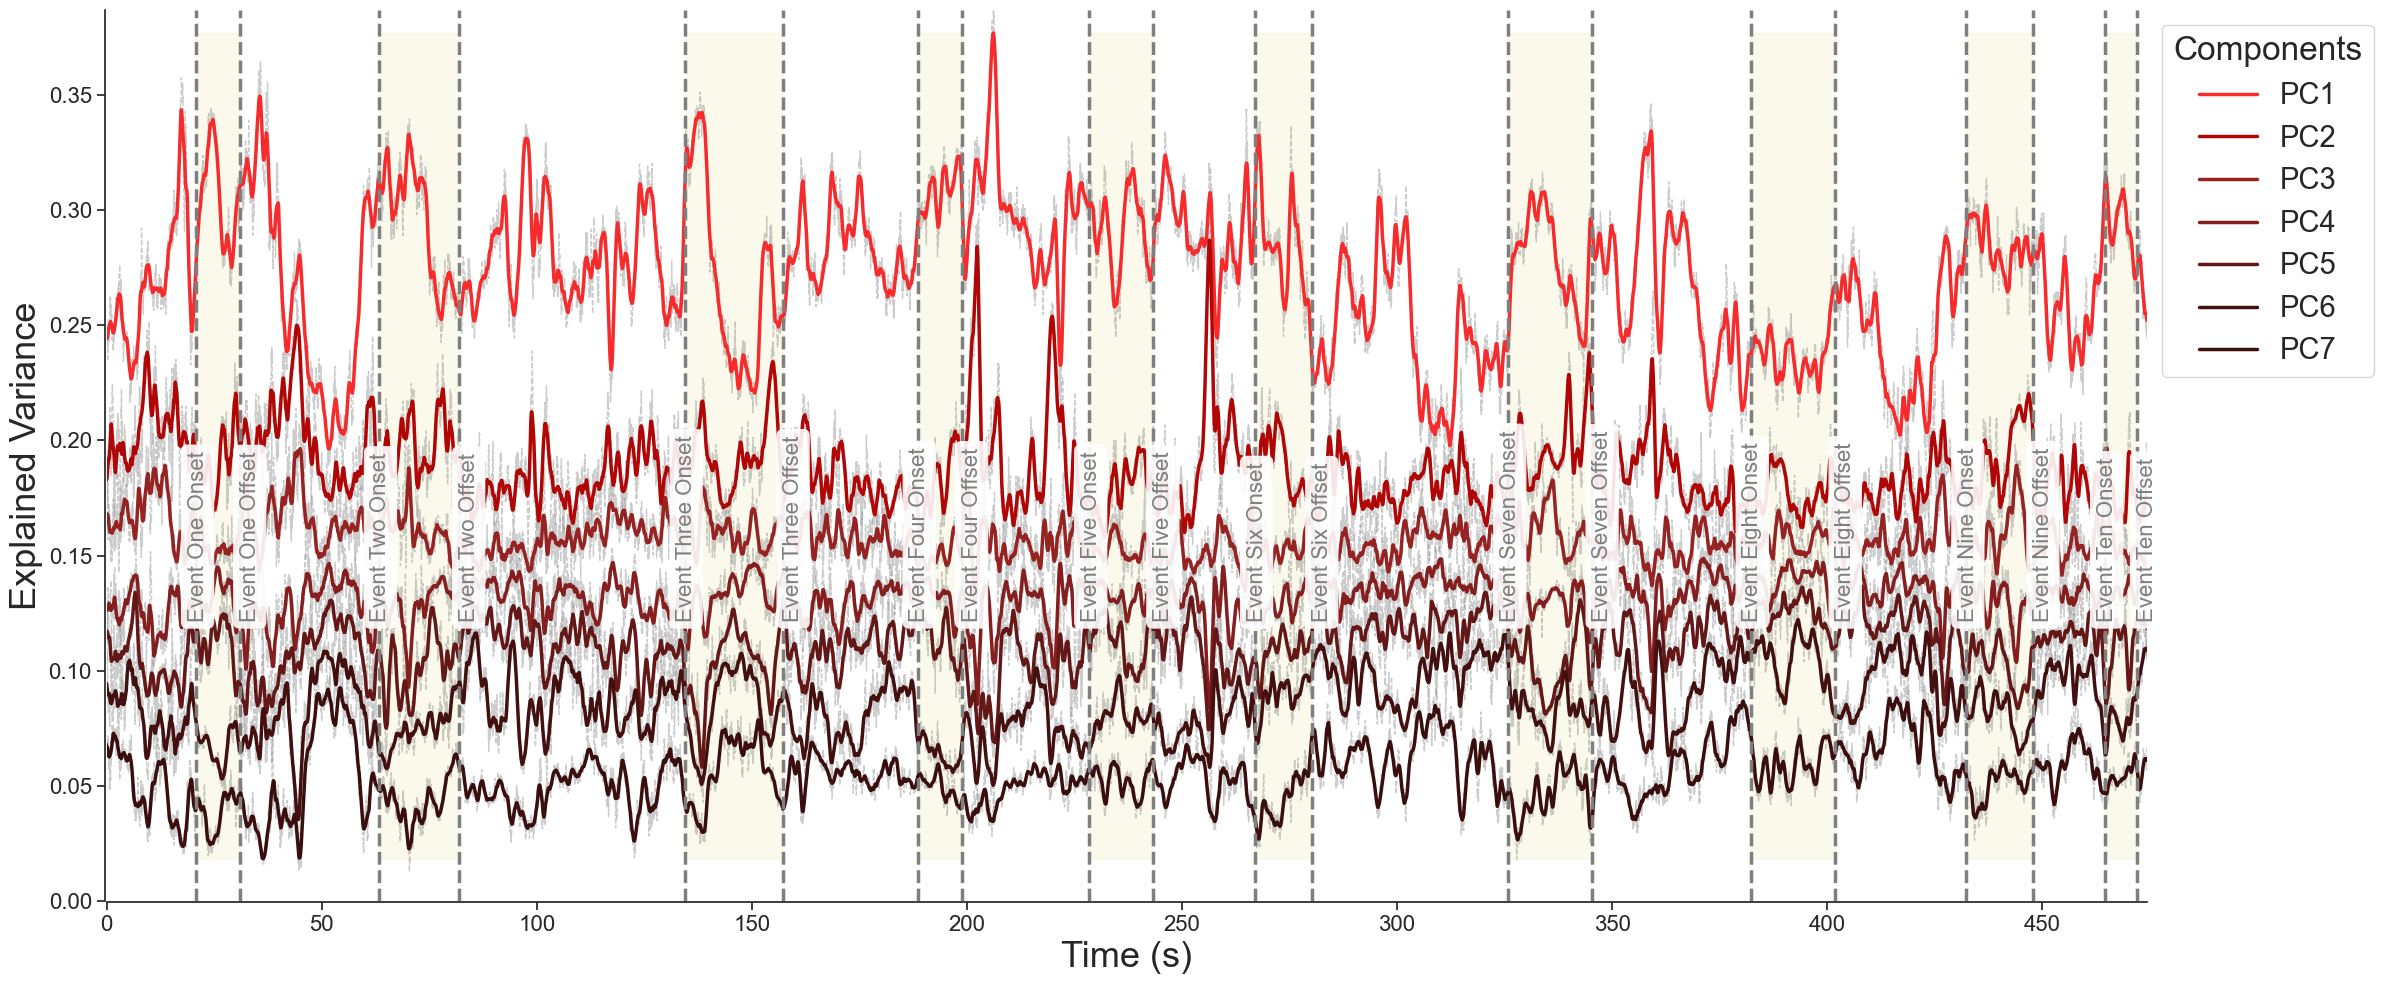

2026-02-03 17:24:37,309 - tornado.application - ERROR - Exception in callback <bound method SystemMonitor.update of <SystemMonitor: cpu: 2 memory: 133 MB fds: 28>>
Traceback (most recent call last):
  File "/Users/johnmadrid/dev/phd_main/lib/python3.11/site-packages/tornado/ioloop.py", line 937, in _run
    val = self.callback()
          ^^^^^^^^^^^^^^^
  File "/Users/johnmadrid/dev/phd_main/lib/python3.11/site-packages/distributed/system_monitor.py", line 168, in update
    net_ioc = psutil.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/johnmadrid/dev/phd_main/lib/python3.11/site-packages/psutil/__init__.py", line 2126, in net_io_counters
    rawdict = _psplatform.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 12] Cannot allocate memory


In [13]:
save_path = 'results/variances/timeplot'
# visualize PCs variance over time
visualize_variance(
    variances_df,
    event='',
    save=True,
    # title='Course of event dynamics on Eye-Head-Car-Steering',
    title="",
    save_name=save_path,
    format='pdf'
)

Visualize variance for one event

Max variance: 23.74; Min variance: 28.66


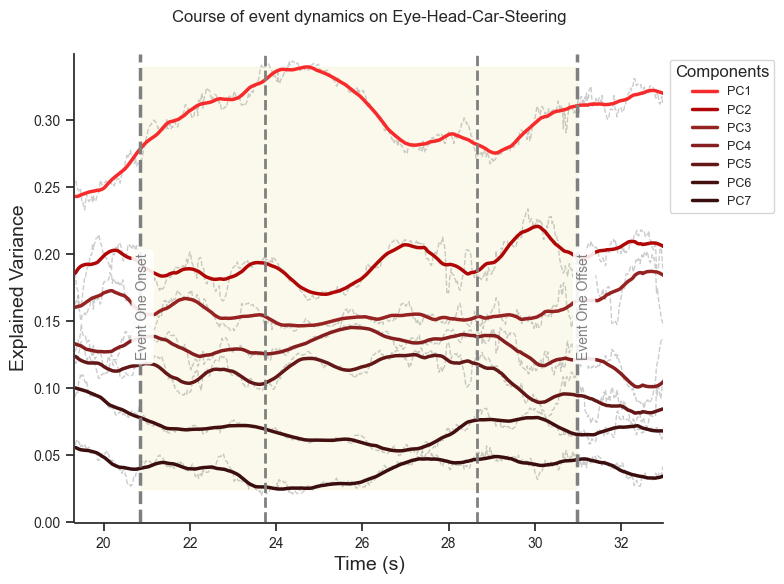

In [19]:
# visualize PCs variance over time

visualize_variance(
    variances_df,
    event='one', 
    save=True, 
    title = 'Course of event dynamics on Eye-Head-Car-Steering',
    save_name=save_path
)

In [23]:
# Calculate mean and std of PC1 and PC2 over the drive
print("Average variance and standard deviation of PC1 and PC2 over the drive:")
print(f"PC1 and PC2 mean and std: \n{variances_df[['PC1', 'PC2']].agg(['mean', 'std'])}")
# variances_df['PC2'].agg(['mean', 'std'])


Average variance and standard deviation of PC1 and PC2 over the drive:
PC1 and PC2 mean and std: 
           PC1       PC2
mean  0.273023  0.187775
std   0.032123  0.018601


In [24]:
# Define the list of events 
event_list = ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']

# Initialize empty DataFrames to collect results for all events
all_min_df = pd.DataFrame()
all_max_df = pd.DataFrame()

for event in event_list:
    _, min_event_df, max_event_df = segment_event(variances_df, event=event)
    # concat min and max dfs for each event
    all_min_df = pd.concat([all_min_df, min_event_df], ignore_index=True)
    all_max_df = pd.concat([all_max_df, max_event_df], ignore_index=True)

print(f"Max cumulative variance per event: \n{all_max_df}")
print(f"Min cumulative variance per event: \n{all_min_df}")

Max cumulative variance per event: 
     Time  Event     PC1-2
0   23.74    one  0.537757
1   70.18    two  0.553067
2  138.64  three  0.571918
3  197.50   four  0.540634
4  237.00   five  0.515562
5  268.48    six  0.528899
6  333.66  seven  0.517120
7  400.88  eight  0.471791
8  436.90   nine  0.513684
9  464.98    ten  0.529163
Min cumulative variance per event: 
     Time  Event     PC1-2
0   28.66    one  0.451084
1   80.42    two  0.436118
2  145.16  three  0.396934
3  189.14   four  0.450010
4  235.58   five  0.413039
5  280.18    six  0.413510
6  325.92  seven  0.416075
7  393.88  eight  0.380242
8  435.68   nine  0.434910
9  471.36    ten  0.436062


Now we extract the proportional variance by each PC at those timepoints

In [25]:
# Subset variances_df where 'Time' matches any value in all_min_df['Time']
subset_min = variances_df[variances_df['Time'].isin(all_min_df['Time'])][['Time', 'Event', 'PC1', 'PC2']].reset_index(drop=True)

# Similarly, for max
subset_max = variances_df[variances_df['Time'].isin(all_max_df['Time'])][['Time', 'Event', 'PC1', 'PC2']].reset_index(drop=True)

print("Subset of variances_df where Time matches all_max_df['Time']:\n", subset_max)
print("Subset of variances_df where Time matches all_min_df['Time']:\n", subset_min)

Subset of variances_df where Time matches all_max_df['Time']:
      Time  Event       PC1       PC2
0   23.74    one  0.339453  0.198305
1   70.18    two  0.336757  0.216310
2  138.64  three  0.344345  0.227573
3  197.50   four  0.325570  0.215064
4  237.00   five  0.321296  0.194266
5  268.48    six  0.309388  0.219511
6  333.66  seven  0.309504  0.207616
7  400.88  eight  0.270816  0.200975
8  436.90   nine  0.311225  0.202459
9  464.98    ten  0.325245  0.203919
Subset of variances_df where Time matches all_min_df['Time']:
      Time  Event       PC1       PC2
0   28.66    one  0.268287  0.182797
1   80.42    two  0.265858  0.170260
2  145.16  three  0.226766  0.170168
3  189.14   four  0.300325  0.149685
4  235.58   five  0.252346  0.160693
5  280.18    six  0.229912  0.183598
6  325.92  seven  0.232622  0.183453
7  393.88  eight  0.223596  0.156646
8  435.68   nine  0.274384  0.160526
9  471.36    ten  0.266358  0.169705


In [26]:
print(f"Average explained variance across all events at max:\n {subset_max[['PC1', 'PC2']].agg(['mean', 'std'])}")
print(f"Average explained variance across all events at min:\n {subset_min[['PC1', 'PC2']].agg(['mean', 'std'])}")

Average explained variance across all events at max:
            PC1       PC2
mean  0.319360  0.208600
std   0.021153  0.010596
Average explained variance across all events at min:
            PC1       PC2
mean  0.254046  0.168753
std   0.025309  0.011933


## PCA event summaries

In [27]:
# List file names in the 'eigenvalues' folder
eigen_results_path = results_dir/'eigenvalues'
eigen_results_files = os.listdir(eigen_results_path)

# Print the file names
print("Files in 'variances' folder:", eigen_results_files)

Files in 'variances' folder: ['event_one', '.DS_Store', 'all_events']


In [28]:
# Load eigenvalues df
# Find CSV files in the 'all_events' folder
all_events_eigv_folder = eigen_results_path / 'all_events'

# Print the names of all CSV files in the folder
csv_files = list((all_events_eigv_folder).glob("*.csv"))
print("CSV files in 'all_events' folder:")
for f in csv_files:
    print(f.name)


CSV files in 'all_events' folder:
eigenval_event_all_events_timestamp_all_7_variables.csv
stddev_event_all_events_timestamp_all_7_variables.csv


Principal components standard deviation results 

In [29]:
# Load all CSV files into a single DataFrame
pcs_stddev_df = dd.read_csv(all_events_eigv_folder / "stddev_event_all_events_timestamp_all_7_variables.csv").compute()

In [30]:
# Subset variances_df where 'Time' matches any value in all_min_df['Time']
pcs_std_min = pcs_stddev_df[pcs_stddev_df['Time'].isin(all_min_df['Time'])][['Time', 'Event', 'PC1_std', 'PC2_std']].reset_index(drop=True)

# Similarly, for max
pcs_std_max = pcs_stddev_df[pcs_stddev_df['Time'].isin(all_max_df['Time'])][['Time', 'Event', 'PC1_std', 'PC2_std']].reset_index(drop=True)

print("PCs standard deviations where Time matches all_max_df['Time']:\n", pcs_std_max)
print("PCs standard deviations where Time matches all_min_df['Time']:\n", pcs_std_min)

PCs standard deviations where Time matches all_max_df['Time']:
      Time  Event   PC1_std   PC2_std
0   23.74    one  1.544204  1.180270
1   70.18    two  1.538060  1.232688
2  138.64  three  1.555291  1.264374
3  197.50   four  1.512298  1.229133
4  237.00   five  1.502339  1.168189
5  268.48    six  1.474234  1.241776
6  333.66  seven  1.474511  1.207663
7  400.88  eight  1.379278  1.188191
8  436.90   nine  1.478605  1.192568
9  464.98    ten  1.511551  1.196868
PCs standard deviations where Time matches all_min_df['Time']:
      Time  Event   PC1_std   PC2_std
0   28.66    one  1.372824  1.133181
1   80.42    two  1.366595  1.093632
2  145.16  three  1.262130  1.093337
3  189.14   four  1.452482  1.025427
4  235.58   five  1.331415  1.062462
5  280.18    six  1.270855  1.135662
6  325.92  seven  1.278323  1.135212
7  393.88  eight  1.253278  1.048998
8  435.68   nine  1.388335  1.061911
9  471.36    ten  1.367887  1.091854


## Course of dimensionality
Here, we extract the PCA results for event 'one' to reconstruct its 'course of dimensionality'. 
We create a table summarising PC1 and PC2 variance, eigenvalue, and standard deviation at the onset of event 'one'


In [31]:
# Load all CSV files into a single DataFrame
eigenv_df = dd.read_csv(all_events_eigv_folder / "eigenval_event_all_events_timestamp_all_7_variables.csv").compute()
eigenv_df

,eigen_val1,eigen_val2,eigen_val3,eigen_val4,eigen_val5,eigen_val6,eigen_val7,Time,Event
0,1.722745,1.304461,1.256684,0.848276,0.770024,0.671892,0.450653,0.00,NoEv
1,1.744587,1.291857,1.217038,0.829385,0.765112,0.728396,0.448359,0.02,NoEv
2,1.774291,1.288383,1.218734,0.806472,0.776707,0.699494,0.460654,0.04,NoEv
3,1.728854,1.379942,1.280174,0.787086,0.770990,0.598830,0.478860,0.06,NoEv
4,1.731458,1.335319,1.275441,0.785825,0.762532,0.644281,0.489877,0.08,NoEv
...,...,...,...,...,...,...,...,...,...
23712,1.752444,1.357745,1.013896,0.973743,0.759734,0.740736,0.426524,474.24,ten_AF
23713,1.748018,1.336871,1.010269,0.963393,0.788962,0.745083,0.432227,474.26,ten_AF
23714,1.721947,1.321324,0.998838,0.968213,0.791138,0.763234,0.460128,474.28,ten_AF
23715,1.718867,1.309034,1.021306,0.947700,0.814435,0.741352,0.472129,474.30,ten_AF


In [32]:
# Extract the first row for event 'one' from each DataFrame
var_row = variances_df[variances_df['Event'] == 'one'].iloc[0]
eigval_row = eigenv_df[eigenv_df['Event'] == 'one'].iloc[0]
std_row = pcs_stddev_df[pcs_stddev_df['Event'] == 'one'].iloc[0]

# Print the onset timestamp (very first timestamp in 'Time' for event 'one')
onset_time = var_row['Time']
print(f"Onset timestamp for event 'one': {onset_time}")

# Build a summary table for PC1 and PC2 at onset of event 'one'
onset_table = pd.DataFrame({
    '': ['Variance', 'Eigenvalue', 'Standard Deviation'],
    'PC1': [var_row['PC1'], eigval_row['eigen_val1'], std_row['PC1_std']],
    'PC2': [var_row['PC2'], eigval_row['eigen_val2'], std_row['PC2_std']]
})

print("Summary table for PC1 and PC2 at onset of event 'one':")
print(onset_table)

Onset timestamp for event 'one': 20.84
Summary table for PC1 and PC2 at onset of event 'one':
                            PC1       PC2
0            Variance  0.267106  0.192198
1          Eigenvalue  1.876349  1.350140
2  Standard Deviation  1.369799  1.161955


In [33]:
# Get min and max event DataFrames for event 'one'
_, min_event_df, max_event_df = segment_event(variances_df, event='one')
min_time = float(min_event_df['Time'])
max_time = float(max_event_df['Time'])
print("Peak PC1-2 variance timestamp:", max_time)


# Extract all relevant information for PC1 and PC2 at pc1-2 max variance of event 'one'
var_df_max = variances_df[(variances_df['Event'] == 'one') & (variances_df['Time'] == max_time)][['PC1', 'PC2']]
eigval_df_max = eigenv_df[(eigenv_df['Event'] == 'one') & (eigenv_df['Time'] == max_time)][['eigen_val1', 'eigen_val2']]
std_df_max = pcs_stddev_df[(pcs_stddev_df['Event'] == 'one') & (pcs_stddev_df['Time'] == max_time)][['PC1_std', 'PC2_std']]

# Create a summary table for PC1 and PC2 at variance peak of event 'one'
summary_table_max = pd.DataFrame({
    '': ['Variance', 'Eigenvalue', 'Standard Deviation'],
    'PC1': [var_df_max['PC1'].values[0], eigval_df_max['eigen_val1'].values[0], std_df_max['PC1_std'].values[0]],
    'PC2': [var_df_max['PC2'].values[0], eigval_df_max['eigen_val2'].values[0], std_df_max['PC2_std'].values[0]]
})

print("Summary table for PC1 and PC2 at variance peak (max) of event 'one':")
print(summary_table_max)

# Extract all relevant information for PC1 and PC2 at pc1-2 min variance of event 'one'
var_df_min = variances_df[(variances_df['Event'] == 'one') & (variances_df['Time'] == min_time)][['PC1', 'PC2']]
eigval_df_min = eigenv_df[(eigenv_df['Event'] == 'one') & (eigenv_df['Time'] == min_time)][['eigen_val1', 'eigen_val2']]
std_df_min = pcs_stddev_df[(pcs_stddev_df['Event'] == 'one') & (pcs_stddev_df['Time'] == min_time)][['PC1_std', 'PC2_std']]

# Create a summary table for PC1 and PC2 at variance drop of event 'one'
summary_table_min = pd.DataFrame({
    '': ['Variance', 'Eigenvalue', 'Standard Deviation'],
    'PC1': [var_df_min['PC1'].values[0], eigval_df_min['eigen_val1'].values[0], std_df_min['PC1_std'].values[0]],
    'PC2': [var_df_min['PC2'].values[0], eigval_df_min['eigen_val2'].values[0], std_df_min['PC2_std'].values[0]]
})
print("\nDrop in PC1-2 variance timestamp:", min_time)
print("Summary table for PC1 and PC2 at variance drop (min) of event 'one':")
print(summary_table_min)

Peak PC1-2 variance timestamp: 23.74
Summary table for PC1 and PC2 at variance peak (max) of event 'one':
                            PC1       PC2
0            Variance  0.339453  0.198305
1          Eigenvalue  2.384565  1.393038
2  Standard Deviation  1.544204  1.180270

Drop in PC1-2 variance timestamp: 28.66
Summary table for PC1 and PC2 at variance drop (min) of event 'one':
                            PC1       PC2
0            Variance  0.268287  0.182797
1          Eigenvalue  1.884646  1.284100
2  Standard Deviation  1.372824  1.133181


# Correlations

In [8]:
from typing import Dict, Iterable, List, Optional

def dimdesc_from_saved_components(
    components_csv_path: str,
    stddev_csv_path: Optional[str] = None,
    eigenvalues_csv_path: Optional[str] = None,
    cleaned_csv_path: Optional[str] = None,
    n_samples: Optional[int] = None,
    time_value: Optional[float] = None,
    event_label: Optional[str] = None,
    axes: Optional[Iterable[int]] = None,
    alpha: Optional[float] = 0.05,
    components_scale: str = "auto",  # {"auto", "eigenvectors", "loadings"}
    time_tolerance: float = 1e-6,
) -> Dict[str, pd.DataFrame]:
    """
    Describe PCA dimensions using saved components and eigenvalues/stddev files, mimicking
    FactoMineR's dimdesc() for quantitative variables.

    This function computes, for a specific time and event label:
      - Correlation of each variable with each requested PC axis
      - Two-sided p-values (H0: correlation = 0) using n-2 degrees of freedom
      - Returns only variables with p < alpha for each axis

    It supports components either as eigenvectors or loadings (correlations). If set to
    components_scale="auto", the function will attempt to detect which one by checking
    whether sum_k (comp_{jk}^2) is close to 1 (loadings) or sum_k ((comp_{jk} * std_k)^2)
    is close to 1 (eigenvectors) for standardized PCA.

    Parameters
    ----------
    components_csv_path : str
        Path to components file with columns `PC1..PCp`, `Features`, `Time`, `Event`.
    stddev_csv_path : str | None
        Path to per-time PC stddev file with columns `PC1_std..PCp_std`, `Time`, `Event`.
        Provide this or `eigenvalues_csv_path` when components are eigenvectors or when
        components_scale="auto".
    eigenvalues_csv_path : str | None
        Path to per-time eigenvalues with columns like `eigen_val1..eigen_valp`, `Time`, `Event`.
        Used only if `stddev_csv_path` is None.
    cleaned_csv_path : str | None
        Deprecated. No longer used. Kept for backward compatibility.
    n_samples : int | None
        Optional number of individuals used to compute the PCA at the selected time/event.
        When not provided, p-values are set to NaN and variables are not filtered by alpha.
    time_value : float | None
        Time to select in the CSVs. If None, the most frequent/first time present is used.
    event_label : str | None
        Event label to select (e.g., "one", "all_events", or "NoEv"). If None, no event
        filtering is applied.
    axes : Iterable[int] | None
        1-based axis indices to describe. Defaults to all PCs present in components.
    alpha : float
        Significance threshold to filter variables per axis.
    components_scale : {"auto", "eigenvectors", "loadings"}
        - "loadings": components are already correlations var↔axis
        - "eigenvectors": components are eigenvectors; multiply by stddev to get correlations
        - "auto": attempt detection using the per-variable energy check
    time_tolerance : float
        Absolute tolerance when matching `time_value` against the `Time` column.

    Returns
    -------
    Dict[str, pd.DataFrame]
        Mapping axis label (e.g., "Dim 1") -> DataFrame with columns:
        ["variable", "correlation", "p_value"], filtered to p < alpha and sorted by
        p ascending then |correlation| descending.
    """
    import re
    from scipy import stats

    # Load components and filter by event/time
    comp_df = pd.read_csv(components_csv_path)

    # Identify PC columns and metadata columns
    pc_cols = [c for c in comp_df.columns if re.fullmatch(r"PC\d+", c)]
    if not pc_cols:
        raise ValueError("No PC columns found in components CSV (expected columns like 'PC1').")

    if axes is None:
        axes_idx_1b = list(range(1, len(pc_cols) + 1))
    else:
        axes_idx_1b = list(axes)

    # Narrow to event if provided
    df = comp_df.copy()
    if event_label is not None and "Event" in df.columns:
        df = df[df["Event"] == event_label]
    
    # Narrow to time if provided, using tolerance
    if time_value is not None and "Time" in df.columns:
        is_close = (df["Time"] - float(time_value)).abs() <= time_tolerance
        if not is_close.any():
            # Try exact comparison for string-like times
            is_close = df["Time"].astype(str) == str(time_value)
        df = df[is_close]

    if df.empty:
        raise ValueError("No component rows remain after filtering by event/time.")

    # For a given time/event, we expect one row per feature
    # Gather stddev per axis for that time/event, if available
    std_by_axis: Dict[int, float] = {}
    if stddev_csv_path is not None or eigenvalues_csv_path is not None:
        if stddev_csv_path is not None:
            sdev_df = pd.read_csv(stddev_csv_path)
            if event_label is not None and "Event" in sdev_df.columns:
                sdev_df = sdev_df[sdev_df["Event"] == event_label]
            if time_value is not None and "Time" in sdev_df.columns:
                is_close = (sdev_df["Time"] - float(time_value)).abs() <= time_tolerance
                if not is_close.any():
                    is_close = sdev_df["Time"].astype(str) == str(time_value)
                sdev_df = sdev_df[is_close]
            if sdev_df.empty:
                raise ValueError("No stddev rows found for the selected event/time.")
            sdev_row = sdev_df.iloc[0].to_dict()
            # Fill stddev for ALL PCs present in components, not only requested axes
            for c in pc_cols:
                a = int(c[2:])
                key = f"PC{a}_std"
                if key in sdev_row and pd.notna(sdev_row[key]):
                    std_by_axis[a] = float(sdev_row[key])
        else:
            eval_df = pd.read_csv(eigenvalues_csv_path)
            if event_label is not None and "Event" in eval_df.columns:
                eval_df = eval_df[eval_df["Event"] == event_label]
            if time_value is not None and "Time" in eval_df.columns:
                is_close = (eval_df["Time"] - float(time_value)).abs() <= time_tolerance
                if not is_close.any():
                    is_close = eval_df["Time"].astype(str) == str(time_value)
                eval_df = eval_df[is_close]
            if eval_df.empty:
                raise ValueError("No eigenvalue rows found for the selected event/time.")
            eval_row = eval_df.iloc[0].to_dict()
            # Fill stddev (sqrt eigenvalue) for ALL PCs present in components
            for c in pc_cols:
                a = int(c[2:])
                key = f"eigen_val{a}"
                if key in eval_row and pd.notna(eval_row[key]):
                    std_by_axis[a] = float(eval_row[key]) ** 0.5

    # Prepare correlations per axis
    # df rows: one per feature; columns: pc_cols + [Features, Time, Event]
    feature_col = "Features" if "Features" in df.columns else None
    if feature_col is None:
        raise ValueError("Components CSV must contain a 'Features' column with variable names.")

    # Auto-detect whether components are eigenvectors or loadings (correlations)
    def detect_components_scale(df_features: pd.DataFrame) -> str:
        # Use all PCs present, compute per-feature energy
        comps = df_features[pc_cols].to_numpy(dtype=float)
        # Build std vector only for PCs we have std for, and mask columns accordingly
        std_values: List[float] = []
        keep_indices: List[int] = []
        for idx, c in enumerate(pc_cols):
            a = int(c[2:])
            if a in std_by_axis:
                keep_indices.append(idx)
                std_values.append(std_by_axis[a])
        if not keep_indices:
            # Cannot scale; default to treat as loadings
            return "loadings"
        comps_sub = comps[:, keep_indices]
        std_vec = np.array(std_values, dtype=float)
        # Compare energies on the same subset of PCs
        energy_as_is = np.mean(np.sum(comps_sub ** 2, axis=1))
        comps_scaled = comps_sub * std_vec[None, :]
        energy_scaled = np.mean(np.sum(comps_scaled ** 2, axis=1))
        # For standardized PCA, per-feature total squared correlation with all PCs ~ 1
        if abs(energy_as_is - 1.0) < abs(energy_scaled - 1.0):
            return "loadings"
        return "eigenvectors"

    scale_mode = components_scale
    if components_scale == "auto":
        scale_mode = detect_components_scale(df)

    # Compute correlation matrix variables x axes
    # Keep only requested axes
    wanted_pc_cols = [f"PC{a}" for a in axes_idx_1b]
    for c in wanted_pc_cols:
        if c not in pc_cols:
            raise ValueError(f"Requested axis column '{c}' not found in components CSV.")

    comps_sel = df[[feature_col] + wanted_pc_cols].copy()
    comps_mat = comps_sel[wanted_pc_cols].to_numpy(dtype=float)

    if scale_mode == "eigenvectors":
        if not std_by_axis:
            raise ValueError(
                "stddev or eigenvalues CSV required when components_scale='eigenvectors' or 'auto'."
            )
        std_vec = np.array([std_by_axis[a] for a in axes_idx_1b], dtype=float)
        corr_mat = comps_mat * std_vec[None, :]
    elif scale_mode == "loadings":
        corr_mat = comps_mat
    else:
        raise ValueError("components_scale must be one of {'auto','eigenvectors','loadings'}")

    # Compute p-values for correlations using t-test with n-2 df
    results: Dict[str, pd.DataFrame] = {}
    for idx, axis_1b in enumerate(axes_idx_1b):
        r_vals = corr_mat[:, idx]
        if n_samples is None or n_samples < 3:
            p_vals = np.full_like(r_vals, fill_value=np.nan, dtype=float)
        else:
            dfree = n_samples - 2
            # Avoid divide-by-zero for |r|==1
            denom = np.maximum(1.0 - (r_vals ** 2), 1e-15)
            t_stat = r_vals * np.sqrt(dfree / denom)
            p_vals = 2.0 * stats.t.sf(np.abs(t_stat), df=dfree)
        axis_df = pd.DataFrame({
            "variable": comps_sel[feature_col].tolist(),
            "r": r_vals,
            "p_value": p_vals,
        })
        # Optional significance filtering (only if p-values are available)
        if (alpha is not None) and axis_df["p_value"].notna().any():
            axis_df = axis_df[axis_df["p_value"].notna()]
            axis_df = axis_df[axis_df["p_value"] < alpha]
        # Order by correlation value descending (most positive to most negative)
        axis_df = axis_df.sort_values(["r"], ascending=[False])
        results[f"PC {axis_1b}"] = axis_df.reset_index(drop=True)

    return results

## Variables correlations with dimensions
We select all the timepoints we want to calculate the variable correlations with PC1 and PC2.
Here, we focus on the onset of event 'one', low-effective dimensionality (ED), and high-ED.

In [9]:
# Use results_dir to construct the path to the components CSV for event 'one'
components_csv_path = os.path.join(results_dir, "components", "event_one", "components_event_one_timestamp_all_7_variables.csv")
stddev_csv_path = os.path.join(results_dir, "eigenvalues", "event_one", "stddev_event_one_timestamp_all_7_variables.csv")


In [36]:
# List of timepoints to analyze
timepoints = [
    ("event_onset", 20.84),
    ("low_ed", 23.74),
    ("high_ed", 28.66),
    ("event_end", 30.98),
]

event_label = "one"

# Prepare to collect all results
all_results = []

# Load stddev_df once outside the loop for efficiency
stddev_df = pd.read_csv(stddev_csv_path)
# Optional: restrict to the event of interest to avoid accidental multi-matches
if "Event" in stddev_df.columns:
    stddev_df = stddev_df[stddev_df["Event"] == event_label]

for label, tval in timepoints:
    res = dimdesc_from_saved_components(
        components_csv_path=components_csv_path,
        stddev_csv_path=stddev_csv_path,
        time_value=tval,
        event_label=event_label,
        axes=[1, 2],
        alpha=0.05,        # for p-values
        n_samples=284,     # number of samples/participants
        components_scale="eigenvectors",
    )
    # For each PC (e.g., "Dim 1", "Dim 2")
    for pc in res:
        axis_df = res[pc].copy()
        axis_df["Time"] = tval
        axis_df["Time_Label"] = label
        axis_df["PC"] = pc
        axis_df["Rank"] = axis_df["r"].rank(ascending=False, method="min").astype(int)
        axis_df["n"] = 284  # or n_samples

        # Get variance explained for this PC at this time
        stddev_row = stddev_df.loc[np.isclose(stddev_df["Time"], tval)]
        if not stddev_row.empty:
            pc_num = int(pc.split()[-1])  # "Dim 1" -> 1

            # Prefer eigenvalues if present; otherwise use squared stddevs
            eigen_cols = [c for c in stddev_row.columns if c.startswith("eigen_val")]
            std_cols = [c for c in stddev_row.columns if c.startswith("PC") and c.endswith("_std")]

            if len(eigen_cols) > 0:
                num_col = f"eigen_val{pc_num}"
                if num_col in stddev_row.columns:
                    eigen_vals = pd.to_numeric(stddev_row.iloc[0][eigen_cols], errors="coerce").to_numpy()
                    numerator = float(stddev_row.iloc[0][num_col])
                    denominator = float(np.nansum(eigen_vals))
                    var_explained = numerator / denominator if denominator > 0 else np.nan
                else:
                    var_explained = np.nan
            elif len(std_cols) > 0:
                std_col = f"PC{pc_num}_std"
                if std_col in stddev_row.columns:
                    s_i = float(stddev_row.iloc[0][std_col])
                    s_all = pd.to_numeric(stddev_row.iloc[0][std_cols], errors="coerce").to_numpy()
                    numerator = s_i ** 2
                    denominator = float(np.nansum(s_all ** 2))
                    var_explained = numerator / denominator if denominator > 0 else np.nan
                else:
                    var_explained = np.nan
            else:
                var_explained = np.nan
        else:
            var_explained = np.nan

        axis_df["var_explained"] = var_explained
        all_results.append(axis_df)

# Concatenate all into a tidy long DataFrame
tidy_corrs = pd.concat(all_results, ignore_index=True)
# Reorder columns for clarity
tidy_corrs = tidy_corrs[
    ["Time", "Time_Label", "PC", "variable", "r", "p_value", "Rank", "n", "var_explained"]
]

# Save to CSV (optional)
tidy_corrs_path = os.path.join(results_dir, "components", "event_one", "variable_correlations_long.csv")
tidy_corrs.to_csv(tidy_corrs_path, index=False)

# Show the first few rows
tidy_corrs

,Time,Time_Label,PC,variable,r,p_value,Rank,n,var_explained
0,20.84,event_onset,PC 1,Head Roll,0.842811,7.557846e-78,1,284,0.267106
1,20.84,event_onset,PC 1,Eye Horizontal,0.191038,1.216125e-03,2,284,0.267106
2,20.84,event_onset,PC 1,Head Yaw,-0.203072,5.751241e-04,3,284,0.267106
3,20.84,event_onset,PC 1,Head Pitch,-0.669368,2.860174e-38,4,284,0.267106
4,20.84,event_onset,PC 1,Eye Vertical,-0.798730,3.599585e-64,5,284,0.267106
5,20.84,event_onset,PC 2,Eye Horizontal,0.639264,4.986475e-34,1,284,0.192198
6,20.84,event_onset,PC 2,Head Pitch,0.327115,1.657849e-08,2,284,0.192198
7,20.84,event_onset,PC 2,Car Yaw,0.127328,3.194949e-02,3,284,0.192198
8,20.84,event_onset,PC 2,Steering,-0.604254,1.179936e-29,4,284,0.192198
9,20.84,event_onset,PC 2,Head Yaw,-0.669969,2.326092e-38,5,284,0.192198
